# Détection des valeurs aberrantes

Méthode 3σ : limites = [26.45, 139.45]
Outliers détectés : Aucun

Méthode 1.5×IQR : limites = [45.38, 130.38]
Outliers détectés : [40]

Score Z modifié : seuil = 3.5
Outliers détectés : Aucun



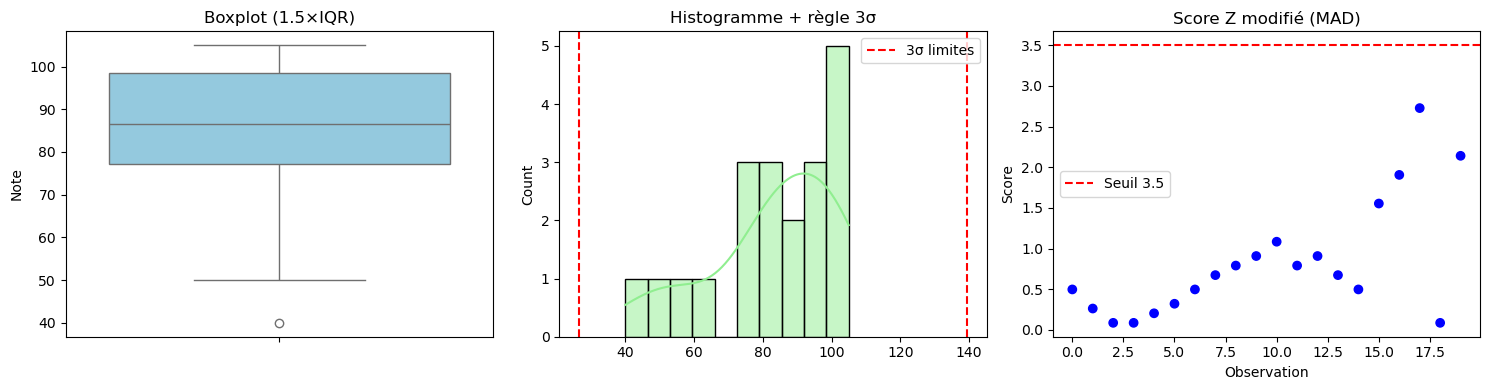


Exemple multivarié :
Seuil de Mahalanobis (97.5%, df=2) : 2.72
Outliers détectés : 1 observation(s)
Indices des outliers : [100]


In [3]:
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
 
# Données exemple (notes de mathématiques)
notes = np.array([78, 82, 85, 88, 90, 92, 95, 98, 100, 102, 105, 
                  100, 102, 75, 78, 60, 54, 40, 85, 50])

# 1. Méthode des 3σ (suppose normalité)
moyenne = np.mean(notes)
ecart_type = np.std(notes, ddof=1)
limites_3sigma = (moyenne - 3*ecart_type, moyenne + 3*ecart_type)
outliers_3sigma = notes[(notes < limites_3sigma[0]) | (notes > limites_3sigma[1])]
print(f"Méthode 3σ : limites = [{limites_3sigma[0]:.2f}, {limites_3sigma[1]:.2f}]")
print(f"Outliers détectés : {outliers_3sigma if len(outliers_3sigma) > 0 else 'Aucun'}\n")

# 2. Méthode 1.5×IQR (robuste, boxplot)
Q1 = np.percentile(notes, 25)
Q3 = np.percentile(notes, 75)
IQR = Q3 - Q1
limites_iqr = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
outliers_iqr = notes[(notes < limites_iqr[0]) | (notes > limites_iqr[1])]
print(f"Méthode 1.5×IQR : limites = [{limites_iqr[0]:.2f}, {limites_iqr[1]:.2f}]")
print(f"Outliers détectés : {outliers_iqr if len(outliers_iqr) > 0 else 'Aucun'}\n")

# 3. Score Z modifié (MAD)
mediane = np.median(notes)
MAD = np.median(np.abs(notes - mediane))
constante = 0.6745  # Pour cohérence avec σ sous normalité
scores_Z_mod = constante * np.abs(notes - mediane) / MAD
outliers_mad = notes[scores_Z_mod > 3.5]
print(f"Score Z modifié : seuil = 3.5")
print(f"Outliers détectés : {outliers_mad if len(outliers_mad) > 0 else 'Aucun'}\n")

# 4. Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Boxplot
sns.boxplot(y=notes, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot (1.5×IQR)')
axes[0].set_ylabel('Note')
 
# Histogramme avec limites 3 sigma
sns.histplot(notes, bins=10, kde=True, ax=axes[1], color='lightgreen')
axes[1].axvline(limites_3sigma[0], color='red', linestyle='--', label='3σ limites')
axes[1].axvline(limites_3sigma[1], color='red', linestyle='--')
axes[1].set_title('Histogramme + règle 3σ')
axes[1].legend()

# Scatter plot des scores Z modifiés
axes[2].scatter(range(len(notes)), scores_Z_mod, c=['red' if z > 3.5 else 'blue' for z in scores_Z_mod])
axes[2].axhline(3.5, color='red', linestyle='--', label='Seuil 3.5')
axes[2].set_title('Score Z modifié (MAD)')
axes[2].set_xlabel('Observation')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.show()

# 5. Exemple multivarié (distance de Mahalanobis)
print("\nExemple multivarié :")
np.random.seed(42)
X = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]], size=100)
# Ajout d'un outlier
X_outlier = np.array([[5, 5]])
X_combined = np.vstack([X, X_outlier])

# Distance de Mahalanobis
cov_matrix = np.cov(X_combined.T)
mean_vector = np.mean(X_combined, axis=0)
inv_cov = np.linalg.inv(cov_matrix)
distances = [np.sqrt((x - mean_vector).T @ inv_cov @ (x - mean_vector)) for x in X_combined]
seuil_mahal = np.sqrt(stats.chi2.ppf(0.975, df=2))  # Seuil à 97.5% pour 2 variables
outliers_mahal = np.array(distances) > seuil_mahal

print(f"Seuil de Mahalanobis (97.5%, df=2) : {seuil_mahal:.2f}")
print(f"Outliers détectés : {np.sum(outliers_mahal)} observation(s)")
print(f"Indices des outliers : {np.where(outliers_mahal)[0].tolist()}")